In [ ]:

import pandas as pd

import seaborn as sns

df = sns.load_dataset('titanic')


print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nColumn info:")
print(df.dtypes)

Shape: (891, 15)

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Column info:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embar

In [2]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df['survived'].value_counts(normalize=True)*100

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [5]:
df.groupby('survived')['age'].mean()

survived
0    30.626179
1    28.343690
Name: age, dtype: float64

In [ ]:

missing = (df.isnull().sum() / len(df) * 100).round(1)
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values (%):")
print(missing)

# Basic statistics
print("\nNumerical summary:")
df.describe().round(2)

Missing values (%):
deck           77.2
age            19.9
embarked        0.2
embark_town     0.2
dtype: float64

Numerical summary:


,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


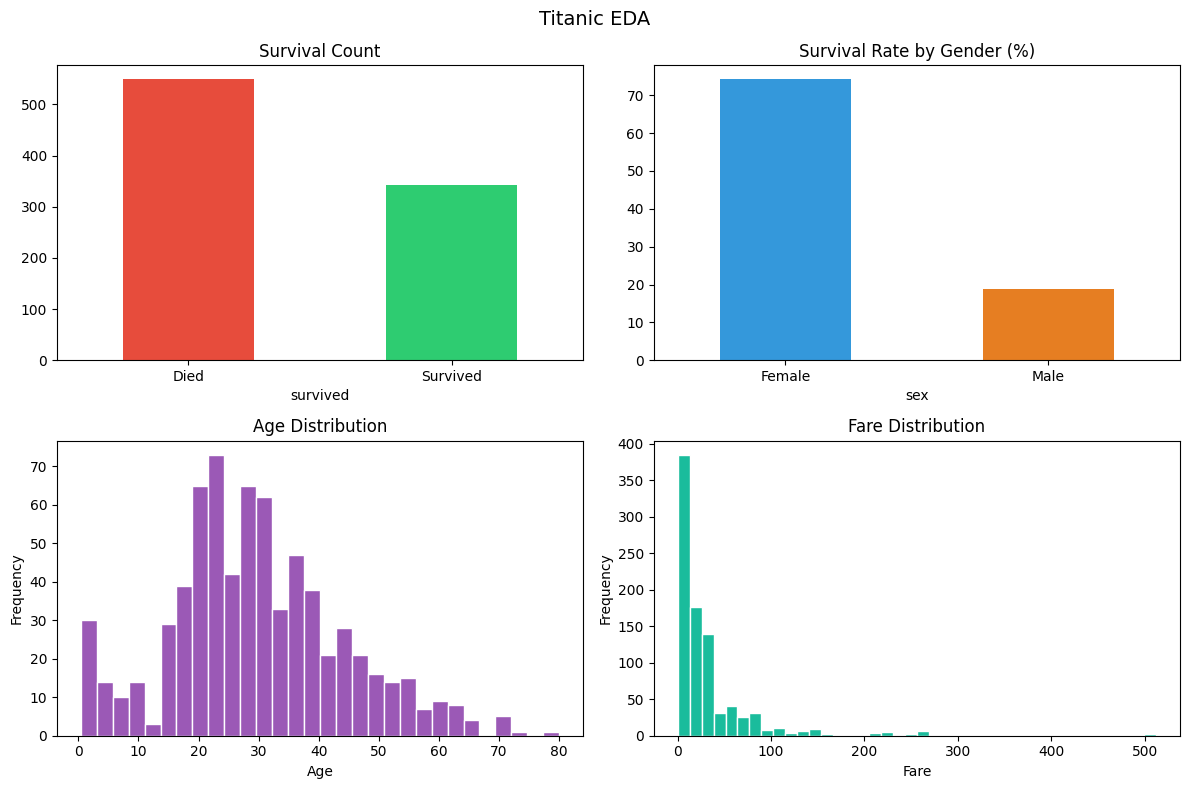

Chart saved to data/titanic_eda.png


In [8]:
# Cell 5 — Visualizations
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Titanic EDA', fontsize=14)

# Chart 1 — Survival count
df['survived'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#e74c3c','#2ecc71'])
axes[0,0].set_title('Survival Count')
axes[0,0].set_xticklabels(['Died','Survived'], rotation=0)

# Chart 2 — Survival by gender
df.groupby('sex')['survived'].mean().mul(100).plot(kind='bar', ax=axes[0,1], color=['#3498db','#e67e22'])
axes[0,1].set_title('Survival Rate by Gender (%)')
axes[0,1].set_xticklabels(['Female','Male'], rotation=0)

# Chart 3 — Age distribution
df['age'].dropna().plot(kind='hist', ax=axes[1,0], bins=30, color='#9b59b6', edgecolor='white')
axes[1,0].set_title('Age Distribution')
axes[1,0].set_xlabel('Age')

# Chart 4 — Fare distribution (log scale because of skew)
df['fare'].plot(kind='hist', ax=axes[1,1], bins=40, color='#1abc9c', edgecolor='white')
axes[1,1].set_title('Fare Distribution')
axes[1,1].set_xlabel('Fare')

plt.tight_layout()
plt.savefig('../data/titanic_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to data/titanic_eda.png")

In [ ]:
# Preparing findings for Claude


findings = {
    "dataset": {
        "total_passengers": len(df),
        "total_features": len(df.columns),
        "missing_age_pct": round(df['age'].isnull().mean()*100, 1),
        "missing_deck_pct": round(df['deck'].isnull().mean()*100, 1),
    },
    "survival": {
        "overall_rate_pct": round(df['survived'].mean()*100, 1),
        "female_survival_pct": round(df[df['sex']=='female']['survived'].mean()*100, 1),
        "male_survival_pct": round(df[df['sex']=='male']['survived'].mean()*100, 1),
        "first_class_pct": round(df[df['pclass']==1]['survived'].mean()*100, 1),
        "second_class_pct": round(df[df['pclass']==2]['survived'].mean()*100, 1),
        "third_class_pct": round(df[df['pclass']==3]['survived'].mean()*100, 1),
    },
    "age": {
        "mean": round(df['age'].mean(), 1),
        "median": round(df['age'].median(), 1),
        "youngest": round(df['age'].min(), 1),
        "oldest": round(df['age'].max(), 1),
    },
    "fare": {
        "median": round(df['fare'].median(), 1),
        "max": round(df['fare'].max(), 1),
        "mean": round(df['fare'].mean(), 1),
    }
}

import json
print(json.dumps(findings, indent=2))

{
  "dataset": {
    "total_passengers": 891,
    "total_features": 15,
    "missing_age_pct": 19.9,
    "missing_deck_pct": 77.2
  },
  "survival": {
    "overall_rate_pct": 38.4,
    "female_survival_pct": 74.2,
    "male_survival_pct": 18.9,
    "first_class_pct": 63.0,
    "second_class_pct": 47.3,
    "third_class_pct": 24.2
  },
  "age": {
    "mean": 29.7,
    "median": 28.0,
    "youngest": 0.4,
    "oldest": 80.0
  },
  "fare": {
    "median": 14.5,
    "max": 512.3,
    "mean": 32.2
  }
}


In [ ]:
# Claude generates the insight report

import os
from dotenv import load_dotenv
from anthropic import Anthropic
from pydantic import BaseModel
from typing import Optional
import json

load_dotenv()
client = Anthropic()

class EDAReport(BaseModel):
    title: str
    executive_summary: str       
    key_findings: list[str]       
    survival_insights: str       
    data_quality_notes: str      
    recommended_next_steps: list[str]  

def generate_report(findings: dict) -> Optional[EDAReport]:
    """Send EDA findings to Claude and get a structured plain-English report."""

    prompt = f"""
    I have completed an exploratory data analysis on the Titanic dataset.
    Here are my findings:

    {json.dumps(findings, indent=2)}

    Write a clear, plain-English report that a non-technical business person could understand.
    Focus on what actually mattered for survival.
    """

    system = """
    You are a senior data scientist writing EDA reports for non-technical stakeholders.

    Rules:
    - Plain English only, no technical jargon
    - Be specific — use the actual numbers from the findings
    - Be concise — every sentence must add value
    - No markdown formatting

    Respond with valid JSON only, using exactly this structure:
    {
        "title": "report title",
        "executive_summary": "2-3 sentence summary",
        "key_findings": ["finding 1", "finding 2", "finding 3", "finding 4"],
        "survival_insights": "paragraph on what drove survival",
        "data_quality_notes": "notes on missing data",
        "recommended_next_steps": ["step 1", "step 2", "step 3"]
    }
    """

    response = client.messages.create(
        model="claude-sonnet-4-5",
        max_tokens=1024,
        system=system,
        messages=[{"role": "user", "content": prompt}]
    )

    raw = response.content[0].text
    raw = response.content[0].text

    raw = raw.strip()
    if raw.startswith("```"):
        raw = raw.split("```")[1]  
        if raw.startswith("json"):
            raw = raw[4:]         
    raw = raw.strip()
    try:
        data = json.loads(raw)
        report = EDAReport(**data)
        return report
    except Exception as e:
        print(f"Failed to parse: {e}")
        print(f"Raw response: {raw}")
        return None


# Generate the report
report = generate_report(findings)

if report:
    print(f"TITLE: {report.title}")
    print(f"\nEXECUTIVE SUMMARY:\n{report.executive_summary}")
    print(f"\nKEY FINDINGS:")
    for i, finding in enumerate(report.key_findings, 1):
        print(f"  {i}. {finding}")
    print(f"\nSURVIVAL INSIGHTS:\n{report.survival_insights}")
    print(f"\nDATA QUALITY:\n{report.data_quality_notes}")
    print(f"\nNEXT STEPS:")
    for i, step in enumerate(report.recommended_next_steps, 1):
        print(f"  {i}. {step}")


TITLE: Titanic Passenger Survival Analysis: What Determined Who Lived and Died

EXECUTIVE SUMMARY:
Of the 891 passengers analyzed, only 38.4% survived the Titanic disaster. Survival was dramatically influenced by gender and social class: women survived at nearly four times the rate of men, and first-class passengers had more than double the survival rate of third-class passengers.

KEY FINDINGS:
  1. Women had a 74.2% survival rate compared to just 18.9% for men, meaning nearly 3 out of 4 women survived while only 1 in 5 men did
  2. First-class passengers survived at a 63.0% rate, second-class at 47.3%, and third-class at only 24.2%, showing a clear advantage for wealthier passengers
  3. The typical passenger was 28 years old and paid 14.50 in fare, though some passengers paid as much as 512.30
  4. Passenger ages ranged from a 5-month-old baby to an 80-year-old, with an average age of about 30 years

SURVIVAL INSIGHTS:
Two factors dominated survival outcomes: gender and ticket class